# Find edge projectors - circuit cluster states - Random FDLU
Created 25/08/2026

Objectives:
* Iterate on [this notebook](find_edge_projectors_circuit_cluster_states_2.ipynb), now applying random FDLU circuits to the cluster state.

# Package imports

In [1]:
import sys

In [2]:
from itertools import chain, combinations
from collections import defaultdict
import re

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os
import pickle

In [4]:
import numpy as np
import jax.numpy as jnp

import pandas as pd

import matplotlib.pyplot as plt
import matplotlib

In [5]:
import quimb as qu
import quimb.tensor as qtn
from quimb.tensor.optimize import TNOptimizer

/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/Users/kierancooney/.pyenv/versions/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


In [6]:
from quspin.operators import hamiltonian
from quspin.operators import quantum_operator
from quspin.basis import spin_basis_1d

In [7]:
from itertools import cycle

# Definitions

## Construct cluster state

In [8]:
np_up_X_state = 1/(np.sqrt(2))*np.array([1,1])

In [9]:
qu_up_X_state = qtn.Tensor(
    data=np_up_X_state,
    inds=('k',),
    tags='prod'
)

In [10]:
np_CZ = np.diag([1,1,1,-1])

In [11]:
np_CZ = np_CZ.reshape((2,)*4)

In [12]:
qu_CZ = qtn.Tensor(
    data=np_CZ,
    inds=('k1', 'k2', 'b1', 'b2'),
    tags='CZ'
)

In [13]:
def get_cluster_state_qu_tensor_network(num_sites):
    assert (num_sites%2) == 0

    product_state_tensors = [
        qu_up_X_state.reindex({'k': f'kc_1_{i}'})
        for i in range(num_sites)
    ]

    first_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_1_{i}',
            'b2': f'kc_1_{i+1}',
            'k1': f'kc_2_{i}',
            'k2': f'kc_2_{i+1}'
        })
        for i in range(0, num_sites, 2)
    ]


    second_layer_circuit_tensors = [
        qu_CZ.reindex({
            'b1': f'kc_2_{i}',
            'b2': f'kc_2_{(i+1)%num_sites}',
            'k1': f'k{i}',
            'k2': f'k{(i+1)%num_sites}'
        })
        for i in range(1, num_sites+1, 2)
    ]

    all_tensors = (
        product_state_tensors
        + first_layer_circuit_tensors
        + second_layer_circuit_tensors
    )

    out = qtn.TensorNetwork(all_tensors, virtual=True)
    out.mangle_inner_()

    return out

## Apply random unitaries

In [14]:
np.power(2, -1/2)

0.7071067811865476

In [15]:
def generate_random_symmetry_respecting_unitary():
    theta = np.random.uniform(0, 2*np.pi, 4)
    diag_phases = np.diag(np.exp(1j * theta))

    np_H = np.power(2, -1/2)*np.array([
        [1,1],
        [1,-1]
    ])

    np_H_2_site = np.kron(np_H, np_H)

    u = (
        np_H_2_site
        @ diag_phases
        @ np_H_2_site
    )

    return u

In [16]:
u = generate_random_symmetry_respecting_unitary()

In [17]:
np.round(u @ u.conj().T, 3)

array([[ 1.+0.j,  0.-0.j, -0.-0.j,  0.-0.j],
       [ 0.+0.j,  1.-0.j,  0.-0.j, -0.-0.j],
       [-0.-0.j,  0.+0.j,  1.-0.j,  0.-0.j],
       [ 0.+0.j, -0.+0.j,  0.-0.j,  1.-0.j]])

In [18]:
np_X = np.array([[0,1],[1,0]])
np_I = np.array([[1,0],[0,1]])

In [19]:
np_X_1 = np.kron(np_X, np_I)
np_X_2 = np.kron(np_I, np_X)

In [20]:
np.linalg.norm(np_X_1 @ u - u @ np_X_1)

0.0

In [21]:
np.linalg.norm(np_X_2 @ u - u @ np_X_2)

0.0

So it is actually unitary.

In [22]:
# Warning, likely making assupmtions about shape of psi, number of sites being even here etc.
def apply_haar_random_fdlu_to_quimb_state(psi, domains_dict):
    num_sites = domains_dict['num_system_sites']

    depth = domains_dict['fdlu_depth']
    offset = domains_dict['fdlu_offset']

    all_circuit_lists = [
        list() for _ in range(depth)
    ]

    for layer, circuit_list in enumerate(all_circuit_lists):
        delta = layer
    
        for i in range(num_sites//2):
            site_1 = ((2*i)+delta+offset)%num_sites
            site_2 = ((2*i)+1+delta+offset)%num_sites

            u = generate_random_symmetry_respecting_unitary()

            inds=[
                f'k_{layer+1}_{site_1}',
                f'k_{layer+1}_{site_2}',
                f'k_{layer}_{site_1}',
                f'k_{layer}_{site_2}'
            ]
            
            qu_u = qtn.Tensor(
                u.reshape((2,)*4),
                inds=inds,
                tags=f'Layer_{layer}'
            )

            circuit_list.append(qu_u)

    all_tensors = (
        [psi.reindex({f'k{i}': f'k_0_{i}' for i in range(num_sites)})]
        + sum(all_circuit_lists, start=[])
    )

    out = (
        qtn
        .TensorNetwork(all_tensors, virtual=False)
        .mangle_inner_()
        .reindex({f'k_{depth}_{i}': f'k{i}' for i in range(num_sites)}) 
    )

    return out

## Symmetries and effective density matrices

In [23]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Z = np.array([[1,0],[0,-1]])

In [24]:
qu_I = qtn.Tensor(np_I, inds=['k', 'b'])
qu_X = qtn.Tensor(np_X, inds=['k', 'b'])
qu_Z = qtn.Tensor(np_Z, inds=['k', 'b'])

In [25]:
symmetry_actions = [
    [qu_I, qu_I],
    [qu_I, qu_X],
    [qu_X, qu_I],
    [qu_X, qu_X]
]

In [26]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

In [27]:
def generate_edm(cut_psi, sites, symmetry_pair, num_defect_sites):
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    psi_bra_reindex_map = (
        {f'k{i}': f'c{i}' for i in left_defect_sites + right_defect_sites}
        | {f'k{i}': f'b{i}' for i in internal_sites}
    )

    edm = (
        cut_psi
        & left_sym_gates
        & inner_gates
        & right_sym_gates
        & cut_psi.conj().reindex(psi_bra_reindex_map)
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## SPT extraction functions

In [28]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [29]:
e, a, b, c = symmetry_labels

In [30]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [31]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [32]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
        if label == symmetry_label
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [33]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

## Optimisation functions

In [34]:
def solve_for_boundary_operators(edm, num_iters=20):
    # Careful, the indices are reversed here for ease.
    # i.e. the k, b indices have been swapped to make tensor contraction easier.
    scores = list()

    u_left = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_left'), edm.ind_size('k_left')),
        inds=['k_left', 'b_left'],
        dtype='complex64'
    )

    u_right = qtn.tensor_builder.rand_tensor(
        (edm.ind_size('b_right'), edm.ind_size('k_right')),
        inds=['k_right', 'b_right'],
        dtype='complex64'
    )

    for _ in range(num_iters):
        right_edm = (edm & u_left).contract()
        data = right_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_right = qtn.Tensor(sol, inds = ['b_right', 'k_right'])
        
        left_edm = (edm & u_right).contract()
        data = left_edm.data
        U, S, VH = np.linalg.svd(data)
        scores.append(np.sum(S))
    
        sol = (U @ VH).conj().T
        u_left = qtn.Tensor(sol, inds = ['b_left', 'k_left'])

    return (u_left, u_right), scores

## Extracting projectors

In [35]:
def random_uniform_complex(shape):
    return np.random.uniform(size=shape) + 1j*np.random.uniform(size=shape)

In [36]:
def lanczos_iteration(rho, v, sites):
    w = (
        rho & v.reindex({f'k{i}': f'b{i}' for i in sites})
    ).contract()

    w_norm = np.sqrt((w & w.conj()).contract())

    out = w/w_norm

    return out

In [37]:
def lanczos_algorithm(rho, v, sites, num_iters=20):
    for _ in range(num_iters):
        v = lanczos_iteration(rho, v, sites)

    return v

In [57]:
def maximize_projector_states(rho):
    # Assume's rho is a single tensor, not a tensor network.
    k_inds = [i for i in rho.outer_inds() if i.startswith('k')]
    #b_inds = [i for i in rho.inds if i.startswith('b')]

    sites = [int(s[1:]) for s in k_inds]

    v = qtn.Tensor(
        data=random_uniform_complex((2,)*len(sites)),
        inds=[f'k{i}' for i in sites]
    )

    v = lanczos_algorithm(
        rho,
        v,
        sites,
        num_iters=20
    )

    new_v = lanczos_iteration(rho, v, sites)

    overlap = np.abs((v & new_v.conj()).contract())

    score = (
        v.reindex({f'k{i}': f'b{i}' for i in sites})
        & rho
        & v.conj()
    )
    score = score.contract()


    return score, v, overlap

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [39]:
def projector_state_check(state, rho, left_sites):
    left_right_rho = (
        rho
        & state
        & state.conj().reindex({s: f'b{s[1:]}' for s in state.inds})
    )

    left_right_rho = left_right_rho.contract()

    left_inds = [
        f'{s}{i}'
        for i in left_sites
        for s in 'kb'
    ]

    schmidt_decomp = qtn.tensor_core.tensor_split(
        left_right_rho,
        left_inds=left_inds,
        method='svd',
        #cutoff=1e-6,
        cutoff_mode='abs',
        absorb=None,
        renorm=False,
        bond_ind='v'
    )

    schmidt_vals = schmidt_decomp.tensors[1]

    return schmidt_vals

# Test

In [81]:
domains_dict = {
    'num_system_sites': 32,
    'symmetry_sites': list(range(7, 12)),
    'left_defect_sites': [4,5],
    'right_defect_sites': [10,11],
    'fdlu_depth': 1,
    'fdlu_offset': 0
}

In [82]:
psi = get_cluster_state_qu_tensor_network(domains_dict['num_system_sites'])

In [83]:
rand_psi = apply_haar_random_fdlu_to_quimb_state(psi, domains_dict)

Check state is symmetric.

In [84]:
num_sites = domains_dict['num_system_sites']

In [85]:
sym_rand_psi_1 = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(1, num_sites, 2)}),
        *[qu_X.reindex({f'{s}': f'{s}{i}' for s in 'kb'}) for i in range(1, num_sites, 2)]
    ]
)

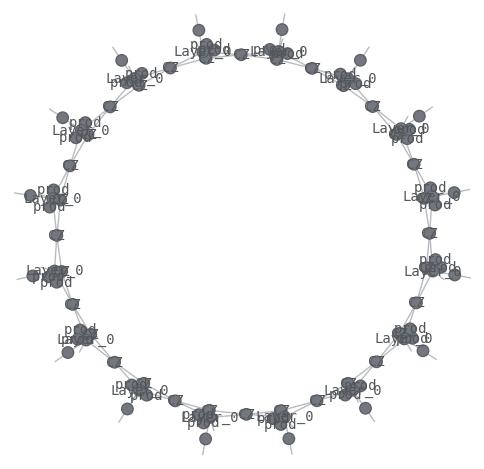

In [86]:
sym_rand_psi_1.draw()

In [87]:
(rand_psi & rand_psi.conj()).contract()

(1.000000000000007-4.439263774066514e-17j)

In [88]:
(sym_rand_psi_1 & sym_rand_psi_1.conj()).contract()

(1.0000000000000073-4.439263774066515e-17j)

In [89]:
np.abs((sym_rand_psi_1 & rand_psi.conj()).contract())

1.0000000000000073

In [90]:
sym_rand_psi_2 = qtn.TensorNetwork(
    [
        rand_psi.reindex({f'k{i}': f'b{i}' for i in range(0, num_sites, 2)}),
        *[qu_X.reindex({f'{s}': f'{s}{i}' for s in 'kb'}) for i in range(0, num_sites, 2)]
    ]
)

In [91]:
(sym_rand_psi_2 & sym_rand_psi_2.conj()).contract()

(1.0000000000000073-3.046063982422632e-17j)

In [92]:
np.abs((sym_rand_psi_2 & rand_psi.conj()).contract())

1.0000000000000075

Ok, state is random and symmetric.

In [93]:
psi = rand_psi

## Left projector

In [106]:
left_rho_sites = [4,5,6,7]

In [107]:
left_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in left_rho_sites}))

In [108]:
left_score, left_proj_vec, left_overlap = maximize_projector_states(left_rho)

In [109]:
left_score

(0.25000000000000183-5.32940034293091e-18j)

In [110]:
left_overlap

1.0

In [111]:
left_score

(0.25000000000000183-5.32940034293091e-18j)

In [112]:
left_sites = [2,3]
right_sites = [8,9]

In [113]:
larger_sites = left_sites + left_rho_sites + right_sites

In [114]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

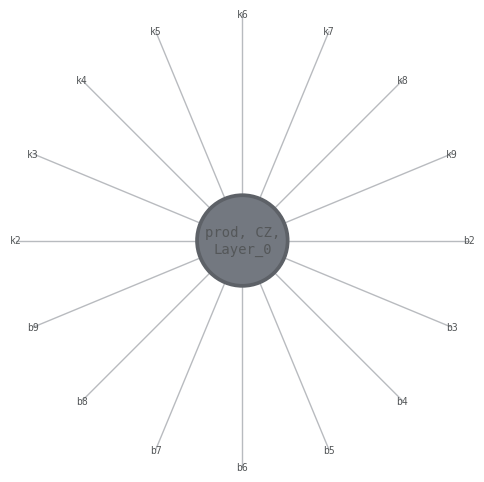

In [115]:
larger_rho.draw()

In [116]:
schmimdt_vals = projector_state_check(
    left_proj_vec,
    larger_rho,
    left_sites
)

In [118]:
schmimdt_vals

Tensor(shape=(4,), inds=('v',), tags=oset(['prod', 'CZ', 'Layer_0']))

Looks ok.

In [119]:
left_proj_vec

Tensor(shape=(2, 2, 2, 2), inds=('k4', 'k5', 'k6', 'k7'), tags=oset(['prod', 'CZ', 'Layer_0']))

## Right projector

In [120]:
right_rho_sites = [24,25,26,27]

In [122]:
right_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in right_rho_sites}))

In [124]:
right_score, right_proj_vec, right_overlap = maximize_projector_states(right_rho)

In [125]:
right_score

(0.25000000000000216-1.22514845490862e-17j)

In [126]:
right_overlap

1.0000000000000004

In [127]:
left_sites = [22,23]
right_sites = [28,29]

In [128]:
larger_sites = left_sites + right_rho_sites + right_sites

In [129]:
larger_rho = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in larger_sites})).contract()

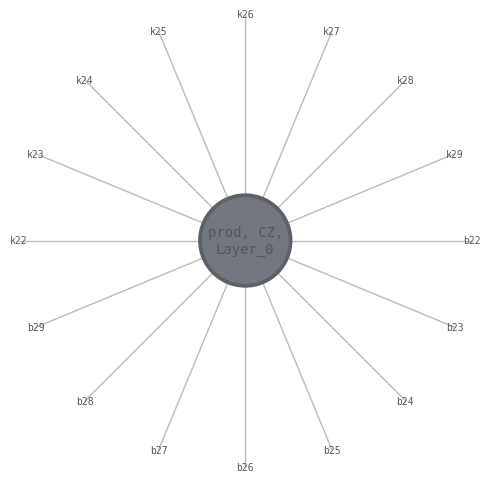

In [130]:
larger_rho.draw()

In [131]:
larger_rho

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k22', 'k23', 'k24', 'k25', 'k26', 'k27', 'k28', 'k29', 'b22', 'b23', 'b24', 'b25', 'b26', 'b27', 'b28', 'b29'), tags=oset(['prod', 'CZ', 'Layer_0']))

In [132]:
schmimdt_vals = projector_state_check(
    right_proj_vec,
    larger_rho,
    left_sites
)

In [133]:
schmimdt_vals

Tensor(shape=(4,), inds=('v',), tags=oset(['prod', 'CZ', 'Layer_0']))

Looks ok.

## Compute cut rho

In [134]:
cut_sites = list(range(4, 28))

In [136]:
left_proj_sites = list(range(4, 8))
right_proj_sites = list(range(24, 28))

In [135]:
cut_rho_unprojected = (psi & psi.conj().reindex({f'k{i}': f'b{i}' for i in cut_sites}))

In [137]:
cut_rho = (
    cut_rho_unprojected.reindex({
            **{f'k{i}': f'l{i}' for i in left_proj_sites},
            **{f'k{i}': f'l{i}' for i in right_proj_sites},
            **{f'b{i}': f'c{i}' for i in left_proj_sites},
            **{f'b{i}': f'c{i}' for i in right_proj_sites}
    })
    & left_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in left_proj_sites})
    & left_proj_vec
    & left_proj_vec.reindex({f'k{i}': f'c{i}' for i in left_proj_sites})
    & left_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in left_proj_sites})
    & right_proj_vec.conj().reindex({f'k{i}': f'l{i}' for i in right_proj_sites})
    & right_proj_vec
    & right_proj_vec.reindex({f'k{i}': f'c{i}' for i in right_proj_sites})
    & right_proj_vec.conj().reindex({f'k{i}': f'b{i}' for i in right_proj_sites})
)

In [138]:
cut_rho_trace = (
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

In [139]:
cut_rho_trace

(0.06250000000000054-2.1955093992831465e-18j)

In [140]:
cut_rho = cut_rho/cut_rho_trace

In [141]:
(
    cut_rho
    .reindex({f'b{i}': f'k{i}' for i in cut_sites})
    .contract()
)

(1+4.5102810375396984e-17j)

In [143]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in cut_sites}
    | {f'b{i}': f'k{i}' for i in cut_sites}
)

In [144]:
(
    (cut_rho & cut_rho.reindex(tranpose_map))
    .contract()
)

(0.306048964952206+1.0299920638612292e-17j)

So the density matrix is not pure, uh oh.

In [148]:
sub_cut_sites = list(range(8, 24))

In [149]:
sub_cut_rho = (
    cut_rho
    .reindex({f'k{i}': f'b{i}' for i in left_proj_sites + right_proj_sites})
)

In [150]:
sub_cut_rho_trace = (
    sub_cut_rho
    .reindex({f'b{i}': f'k{i}' for i in sub_cut_sites})
    .contract()
)

In [151]:
sub_cut_rho_trace

(1+4.5102810375396984e-17j)

In [152]:
tranpose_map = (
    {f'k{i}': f'b{i}' for i in sub_cut_sites}
    | {f'b{i}': f'k{i}' for i in sub_cut_sites}
)

In [153]:
(
    (sub_cut_rho & sub_cut_rho.reindex(tranpose_map))
    .contract()
)

(0.306048964952206+1.0299920638612292e-17j)

## Lanczos algorithm to extract state

In [155]:
cut_score, cut_state, cut_overlap = maximize_projector_states(sub_cut_rho)

In [156]:
cut_score

(0.439383515675127-6.938893903907228e-18j)

In [157]:
cut_overlap

0.9999999999993028

That eigenvalue should be one, ideally.

In [158]:
cut_state

Tensor(shape=(2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2), inds=('k8', 'k9', 'k10', 'k11', 'k12', 'k13', 'k14', 'k15', 'k16', 'k17', 'k18', 'k19', 'k20', 'k21', 'k22', 'k23'), tags=oset(['prod', 'CZ', 'Layer_0']))

In [159]:
(cut_state & cut_state.conj()).contract()

(0.9999999999999966+1.6263032587282567e-18j)

In [160]:
rho_state = (
    sub_cut_rho & cut_state.reindex({f'k{i}': f'b{i}' for i in sub_cut_sites})
).contract()

In [161]:
(rho_state & rho_state.conj()).contract()

(0.19305787384730191+1.6263032587282567e-19j)

In [162]:
(cut_state & rho_state.conj()).contract()

(0.43938351567512446+7.047314121155779e-19j)

## Extract cut rho and EDM

In [163]:
def generate_edm_from_cut_state(cut_state, sites, symmetry_pair, num_defect_sites):
    # Lots of duplicate code, probably a better way to do this.
    assert 2*num_defect_sites < len(sites)

    left_defect_sites = sites[:num_defect_sites]
    right_defect_sites = sites[-num_defect_sites:]
    internal_sites = sites[num_defect_sites:-num_defect_sites]

    # Being sloppy with the gate indices as the symmetries are invariant
    # under transpose and conjugation.
    left_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in left_defect_sites
    ]

    inner_gates = [
        symmetry_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in internal_sites
    ]

    right_sym_gates = [
        symmetry_pair[i%2].reindex({'k': f'b{i}', 'b': f'c{i}'})
        for i in right_defect_sites
    ]

    reindex_map = (
        {
            f'k{i}': f'c{i}'
            for i in (left_defect_sites + right_defect_sites)
        }
        |
        {
            f'k{i}': f'b{i}'
            for i in internal_sites
        }
    )

    edm = (
        cut_state
        & cut_state.conj().reindex(reindex_map)
        & left_sym_gates
        & inner_gates
        & right_sym_gates
    )

    edm = edm.contract()

    fuse_maps = [
        ('k_left', (f'k{i}' for i in left_defect_sites)),
        ('b_left', (f'b{i}' for i in left_defect_sites)),
        ('k_right', (f'k{i}' for i in right_defect_sites)),
        ('b_right', (f'b{i}' for i in right_defect_sites))
    ]

    edm.fuse(fuse_maps, inplace=True)

    return edm

## SPT extraction functions

In [165]:
num_defect_sites = 4

In [166]:
edms = [
    generate_edm_from_cut_state(
        cut_state,
        sub_cut_sites,
        s,
        num_defect_sites
    )
    for s in symmetry_actions[1:]
]

In [167]:
defect_ops_results = [
    solve_for_boundary_operators(edm, num_iters=20)
    for edm in edms
]

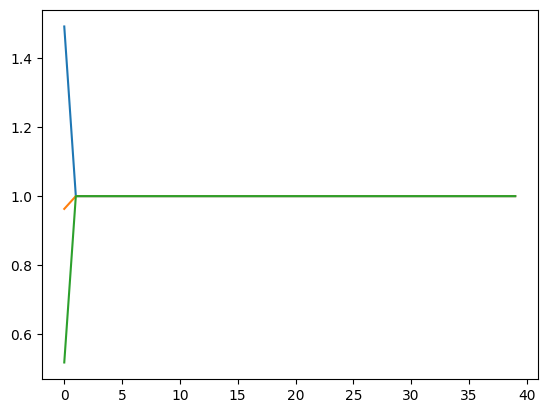

In [177]:
for l in defect_ops_results:
    plt.plot(l[1])

In [178]:
symmetry_combination_labels = list(combinations(symmetry_labels, 2))

In [179]:
symmetry_combination_labels

[('II', 'IX'),
 ('II', 'XI'),
 ('II', 'XX'),
 ('IX', 'XI'),
 ('IX', 'XX'),
 ('XI', 'XX')]

In [180]:
e, a, b, c = symmetry_labels

In [181]:
group_products = [
    (a, b, c),
    (b, a, c),
    (a, c, b),
    (c, a, b),
    (c, b, a),
    (b, c, a)
]

In [182]:
def get_proj_rep_phase(cut_rho, r_g, r_h, r_gh, u_g, left_right):
    k_ind = f'k_{left_right}'
    b_ind = f'b_{left_right}'

    invariant_tn = (
        cut_rho
        & r_g.reindex({b_ind: 'i1'})
        & u_g.conj().reindex({k_ind: 'i1', b_ind: 'i2'})
        & r_h.reindex({k_ind: 'i2', b_ind: 'i3'})
        & u_g.reindex({b_ind: 'i3', k_ind: 'i4'})
        & r_gh.conj().reindex({b_ind: 'i4', k_ind: b_ind})
    )

    out = invariant_tn.contract()

    return out

In [183]:
symmetry_labels

['II', 'IX', 'XI', 'XX']

In [184]:
def get_defect_symmetry_gate(symmetry_label, defect_sites, left_right):
    sym_pair = next(
        pair for label, pair in zip(symmetry_labels, symmetry_actions)
        if label == symmetry_label
    )

    sym_gates = [
        sym_pair[i%2].reindex({'k': f'k{i}', 'b': f'b{i}'})
        for i in defect_sites
    ]

    fuse_map = [
        (f'k_{left_right}', (f'k{i}' for i in defect_sites)),
        (f'b_{left_right}', (f'b{i}' for i in defect_sites))
    ]
   
    gate = (
        qtn
        .TensorNetwork(sym_gates)
        .contract()
        .fuse(fuse_map)
    )

    return gate

In [185]:
def get_proj_rep_phases(rho, unitaries, left_right, defect_sites):
    out = list()

    unitaries_dict = {
        k: v for k, v in zip(symmetry_labels[1:], unitaries)
    }

    out_phases = list()
    for a, b, c in group_products:
        sym_gate = get_defect_symmetry_gate(
            a, defect_sites, left_right
        )

        phase = get_proj_rep_phase(
            rho,
            unitaries_dict[a],
            unitaries_dict[b],
            unitaries_dict[c],
            sym_gate,
            left_right
        )

        out_phases.append(phase)

    return out_phases

In [186]:
sub_cut_sites

[8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]

In [187]:
left_defect_sites = [8, 9, 10, 11]
right_defect_sites = [20, 21, 22, 23]

In [188]:
left_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in left_defect_sites
    })
)
left_rdm = left_rdm.contract()
left_fuse_map = [
    ('k_left', [f'k{i}' for i in left_defect_sites]),
    ('b_left', [f'b{i}' for i in left_defect_sites])
]
left_rdm.fuse(left_fuse_map, inplace=True)

right_rdm = (
    cut_rho
    .reindex({
        f'b{i}': f'k{i}'
        for i in cut_sites if i not in right_defect_sites
    })
)
right_rdm = right_rdm.contract()
right_fuse_map = [
    ('k_right', [f'k{i}' for i in right_defect_sites]),
    ('b_right', [f'b{i}' for i in right_defect_sites])
]
right_rdm.fuse(right_fuse_map, inplace=True)

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ', 'Layer_0']))

In [189]:
left_rdm

Tensor(shape=(16, 16), inds=('k_left', 'b_left'), tags=oset(['prod', 'CZ', 'Layer_0']))

In [190]:
right_rdm

Tensor(shape=(16, 16), inds=('k_right', 'b_right'), tags=oset(['prod', 'CZ', 'Layer_0']))

In [191]:
unitary_pairs = [l[0] for l in defect_ops_results]
left_unitaries, right_unitaries = zip(*unitary_pairs)

In [192]:
left_unitaries

(Tensor(shape=(16, 16), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('b_left', 'k_left'), tags=oset([])),
 Tensor(shape=(16, 16), inds=('b_left', 'k_left'), tags=oset([])))

In [193]:
left_fuse_map

[('k_left', ['k8', 'k9', 'k10', 'k11']),
 ('b_left', ['b8', 'b9', 'b10', 'b11'])]

In [195]:
left_phases = np.array(get_proj_rep_phases(left_rdm, left_unitaries, 'left', left_defect_sites))

In [196]:
left_phases

array([ 0.39980918-0.58328034j, -0.41262112+0.53761819j,
        0.11798976+0.61886042j, -0.15093749-0.65016799j,
       -0.61967642-0.46956304j,  0.44596779+0.43143604j])

In [197]:
np.abs(left_phases)

array([0.70715157, 0.67770902, 0.63000778, 0.66745827, 0.77748847,
       0.62050329])

In [198]:
left_phases[::2]/left_phases[1::2]

array([-1.0419394 +0.05601935j, -0.94314657-0.03747711j,
       -1.24392697+0.15048594j])

In [200]:
right_phases = np.array(get_proj_rep_phases(
    right_rdm,
    right_unitaries,
    'right',
    right_defect_sites
))

In [201]:
right_phases

array([ 0.33963478+0.49176398j, -0.35818733-0.48231407j,
        0.17496228-0.70721989j, -0.23887361+0.65598295j,
       -0.4613816 +0.37878926j,  0.50415546-0.38359941j])

In [202]:
np.abs(right_phases)

array([0.59764839, 0.60077035, 0.72854085, 0.69812193, 0.59695418,
       0.6334992 ])

In [203]:
right_phases[::2]/right_phases[1::2]

array([-0.99421636-0.03417052j, -1.03763808+0.1111341j ,
       -0.94166806+0.03484232j])

But the invariants aren't bad actually! Write

# Conclusions
It somewhat works!